In [ ]:
# ── Memory setup: must run BEFORE any torch import ──────────────────────────
# expandable_segments reduces fragmentation (the primary cause of OOM on T4).
# This env var is also set inside run_experiment.py, but setting it here
# ensures it applies to ALL CUDA allocations in the notebook process too.
import os
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

# Optional: limit per-process reserved memory so back-to-back model loads
# don't carry stale reservations into the next experiment.
import gc
def free_gpu():
    gc.collect()
    try:
        import torch
        torch.cuda.empty_cache()
    except Exception:
        pass

print('PYTORCH_ALLOC_CONF =', os.environ['PYTORCH_ALLOC_CONF'])
print('Memory helpers ready.')

PYTORCH_ALLOC_CONF = expandable_segments:True
Memory helpers ready.


# Salient-Quant: Complete Experiment Runner
**CS595-2 · Illinois Tech · Anshul Dani & Rohit Lahori**

**Before running:** `Runtime → Change runtime type → T4 GPU`

This notebook runs all three milestones:
- **Exp 1** – GPT-2 small: baselines + ours (~15 min)
- **Exp 2** – GPT-2 medium: baselines + ours + 2 ablations, Milestone B (~60 min)
- **Exp 3** – LLaMA-3.2-1B: baselines + ours + 6 ablations + MMLU, Milestone C (~90 min)

## Step 0 — Verify GPU

In [ ]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError('No GPU detected. Go to Runtime → Change runtime type → GPU (T4) and re-run.')

gpu = torch.cuda.get_device_properties(0)
print(f'GPU:  {gpu.name}')
print(f'VRAM: {gpu.total_memory / 1e9:.1f} GB')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA:    {torch.version.cuda}')

GPU:  Tesla T4
VRAM: 15.6 GB
PyTorch: 2.10.0+cu128
CUDA:    12.8


## Step 1 — Clone Repository

In [ ]:
import os

GITHUB_USERNAME = 'anshuldani'  # <-- change this
REPO_NAME = 'Simplified-Quantization-for-Edge-Ready-Language-Models'

if not os.path.exists(REPO_NAME):
    os.system(f'git clone https://github.com/{GITHUB_USERNAME}/{REPO_NAME}.git')
else:
    print('Repo already cloned, pulling latest...')
    os.system(f'cd {REPO_NAME} && git pull')

os.chdir(REPO_NAME)
print(f'Working directory: {os.getcwd()}')

Working directory: /content/Simplified-Quantization-for-Edge-Ready-Language-Models


## Step 2 — Install Dependencies

In [ ]:
import subprocess
subprocess.run(['pip','install','-q','-r','requirements_colab.txt'])
print('Done.')

Done.


## Step 3 — HuggingFace Login (for LLaMA-3.2)

LLaMA-3.2 is gated. Request access at https://huggingface.co/meta-llama/Llama-3.2-1B
then get your token at https://huggingface.co/settings/tokens

In [ ]:
from huggingface_hub import login

HF_TOKEN = 'HF_TOKEN'  # <-- paste your token
login(token=HF_TOKEN, add_to_git_credential=False)
print('Logged in.')

Logged in.


## Step 4 — Mount Google Drive (recommended)

Preserves results if the session disconnects.

In [ ]:
SAVE_TO_DRIVE = True  # set False to skip

if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR = '/content/drive/MyDrive/salient-quant-results'
    import os; os.makedirs(DRIVE_DIR, exist_ok=True)
    print(f'Results will sync to: {DRIVE_DIR}')
else:
    DRIVE_DIR = None
    print('Drive not mounted.')

Mounted at /content/drive
Results will sync to: /content/drive/MyDrive/salient-quant-results


## Helper — Pretty-print results

In [ ]:
import json
from pathlib import Path

def print_results(results_dir):
    p = Path(results_dir)
    files = list(p.glob('*_results.json'))
    if not files:
        print(f'No results in {results_dir}')
        return
    data = json.load(open(files[0]))
    print(f"\n{'='*65}")
    print(f"  {files[0].name}")
    print(f"{'='*65}")
    print(f"{'Method':<22} {'Bits':>6} {'WT2 PPL':>10} {'PTB PPL':>10} {'MMLU%':>8}")
    print('-'*60)
    for name, res in data.get('models', {}).items():
        bits  = res.get('avg_bits', '?')
        ppl2  = res.get('ppl_wikitext2', {}).get('perplexity', res.get('ppl_wikitext2', {}).get('error','?'))
        pplp  = res.get('ppl_ptb',      {}).get('perplexity', res.get('ppl_ptb',      {}).get('error','-'))
        mmlu  = res.get('mmlu',         {}).get('mmlu_macro_avg_pct', '-')
        fmt = lambda x: f'{x:.2f}' if isinstance(x, float) else str(x)
        print(f"{name:<22} {fmt(bits):>6} {fmt(ppl2):>10} {fmt(pplp):>10} {fmt(mmlu):>8}")

def print_ablation(results_dir, pattern='ablation_*.json'):
    for f in sorted(Path(results_dir).glob(pattern)):
        data = json.load(open(f))
        print(f"\n{'='*55}\n  {f.name}\n{'='*55}")
        print(f"{'Config':<28} {'PPL':>10} {'Bits':>8}")
        print('-'*48)
        for cfg_name, res in data.items():
            print(f"{cfg_name:<28} {res['perplexity']:>10.2f} {res['avg_bits']:>8.3f}")

print('Helpers ready.')

Helpers ready.


---
## Experiment 1 — GPT-2 Small Baseline + Ours
**~15 min on T4** | Config: `configs/gpt2_colab.yaml`

FP16 + Uniform INT2 + BitNet + Ours (1.61b), WikiText-2 perplexity.

In [ ]:
import os
os.system('python experiments/run_experiment.py --config configs/gpt2_colab.yaml')

In [ ]:
print_results('results/gpt2_colab')

from IPython.display import Image, display
import glob
for png in sorted(glob.glob('results/gpt2_colab/plots/*.png')):
    print(f'\n{png}')
    display(Image(png))

if SAVE_TO_DRIVE:
    os.system(f'cp -r results/gpt2_colab {DRIVE_DIR}/')

---
## Experiment 2 — GPT-2 Medium Full + Ablations (Milestone B)
**~60 min on T4** | Config: `configs/gpt2_full.yaml`

GPT-2 medium (345M): baselines + ours + ablations: salience_metric, granularity.
Evaluates WikiText-2, PTB, latency.

In [ ]:
os.system('python experiments/run_experiment.py --config configs/gpt2_full.yaml')

0


  gpt2_full_milestone_b_results.json
Method                   Bits    WT2 PPL    PTB PPL    MMLU%
------------------------------------------------------------
fp16                    16.00      21.64      22.53        -
uniform_int2             2.00 1451721.25 1310860.69        -
bitnet                   1.58 1556522.15 1448813.68        -
ours                     1.61     541.05     547.75        -

  ablation_granularity.json
Config                              PPL     Bits
------------------------------------------------
weight                          5680.90    1.610
channel                       872569.04    1.741
layer                        1654710.16    1.542

  ablation_salience_metric.json
Config                              PPL     Bits
------------------------------------------------
magnitude_l1                    9273.84    1.610
magnitude_l2                    9095.17    1.611
gradient                       72670.99    1.610
hessian                       243575.38    2

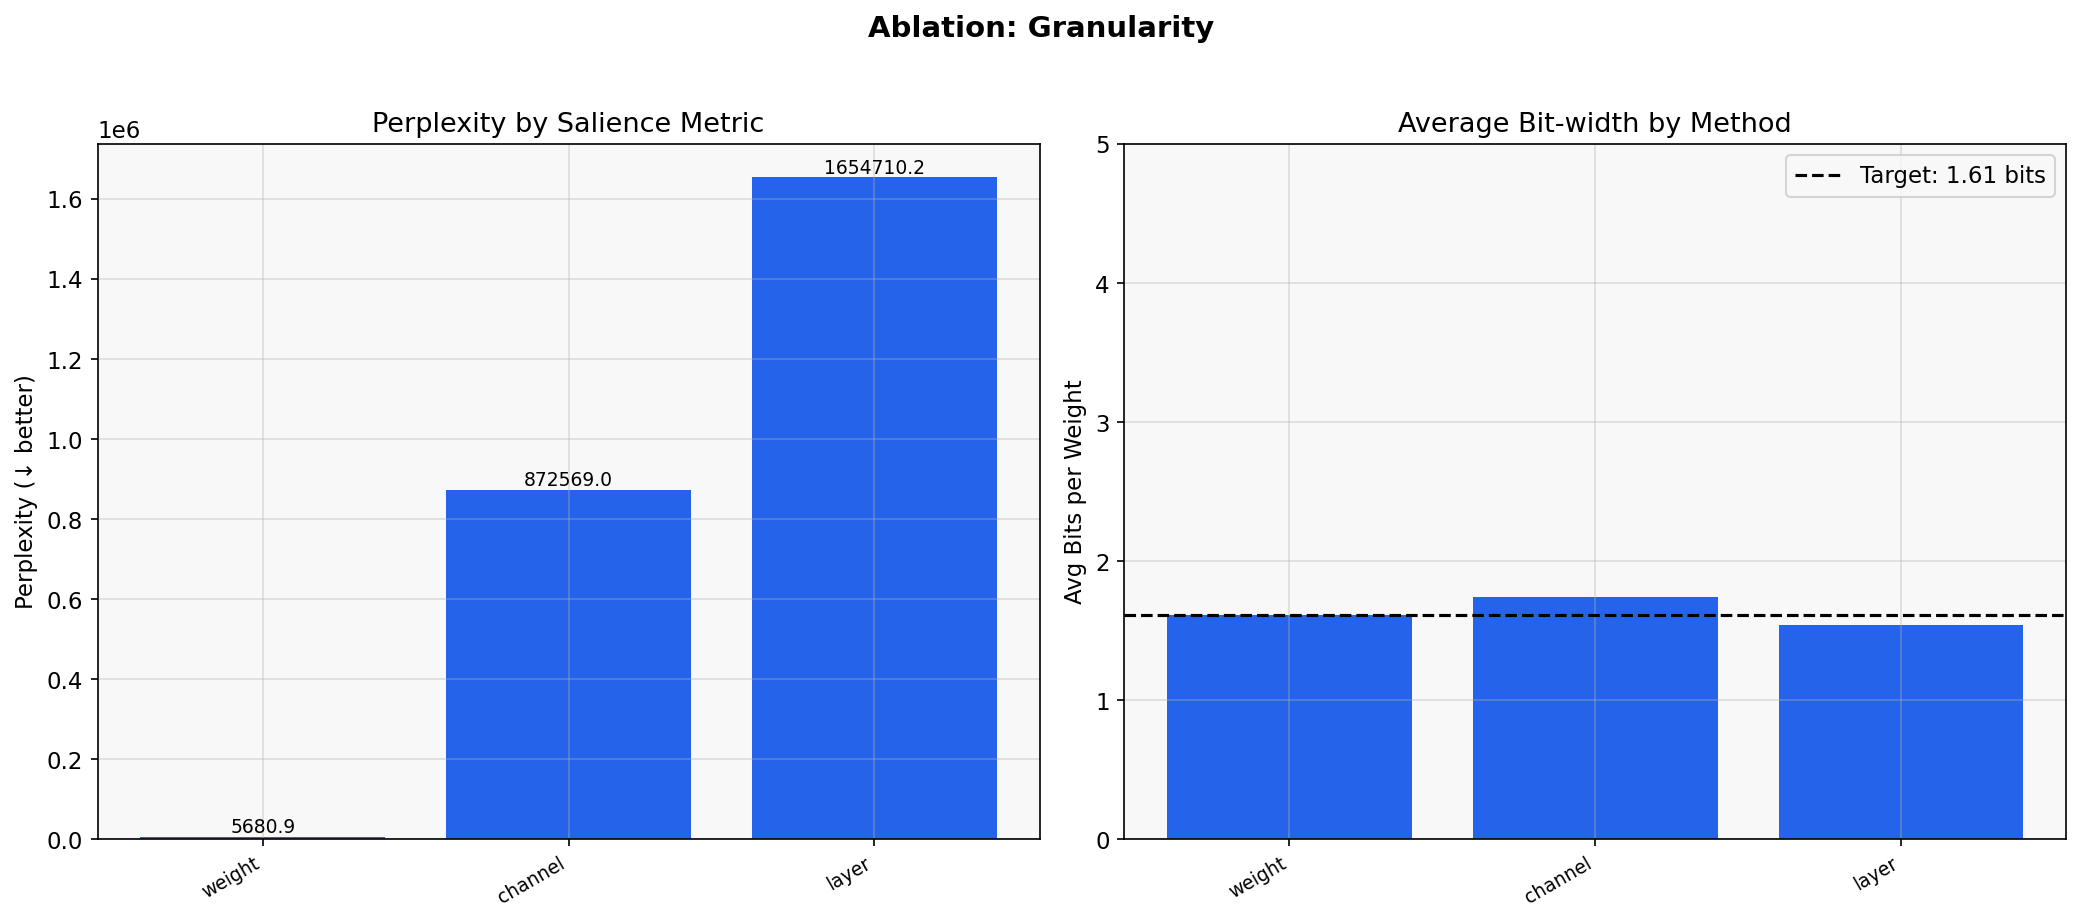


results/gpt2_full/plots/ablation_salience_metric.png


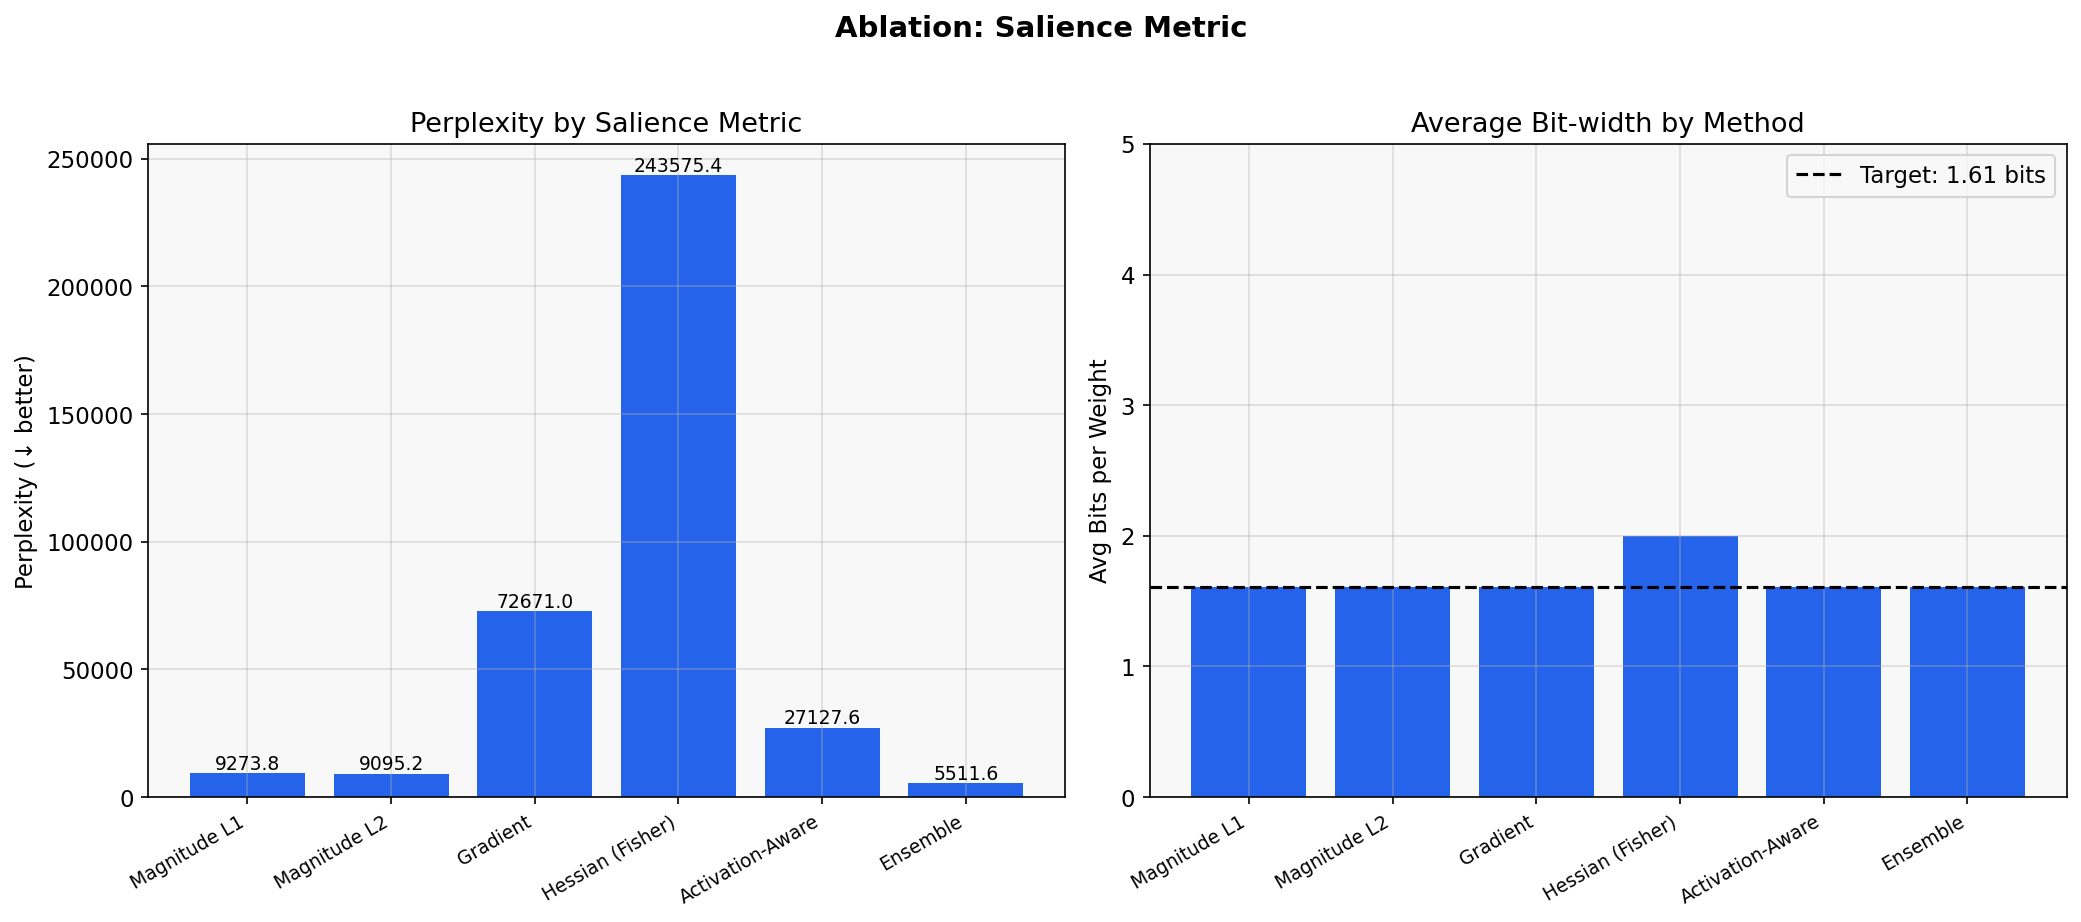


results/gpt2_full/plots/baseline_comparison.png


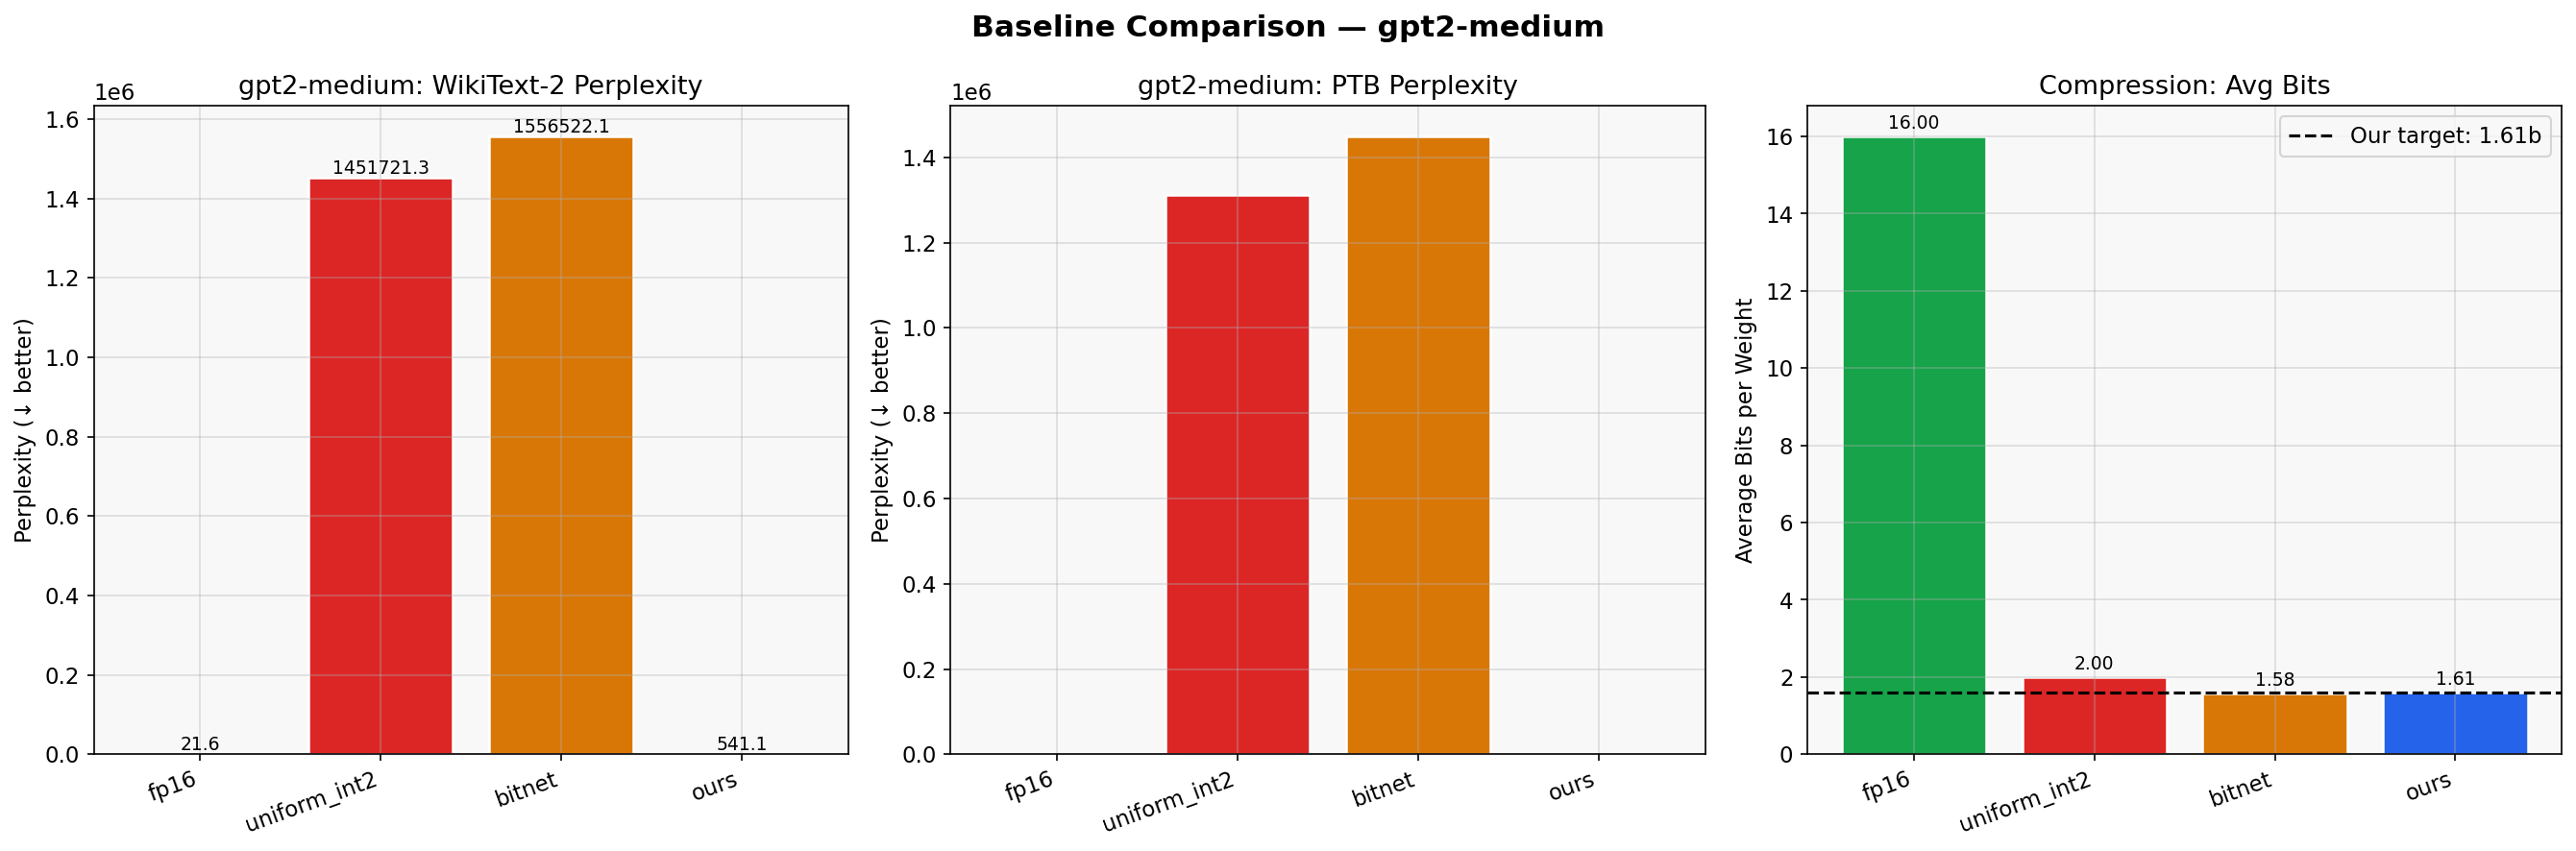


results/gpt2_full/plots/bit_allocation.png


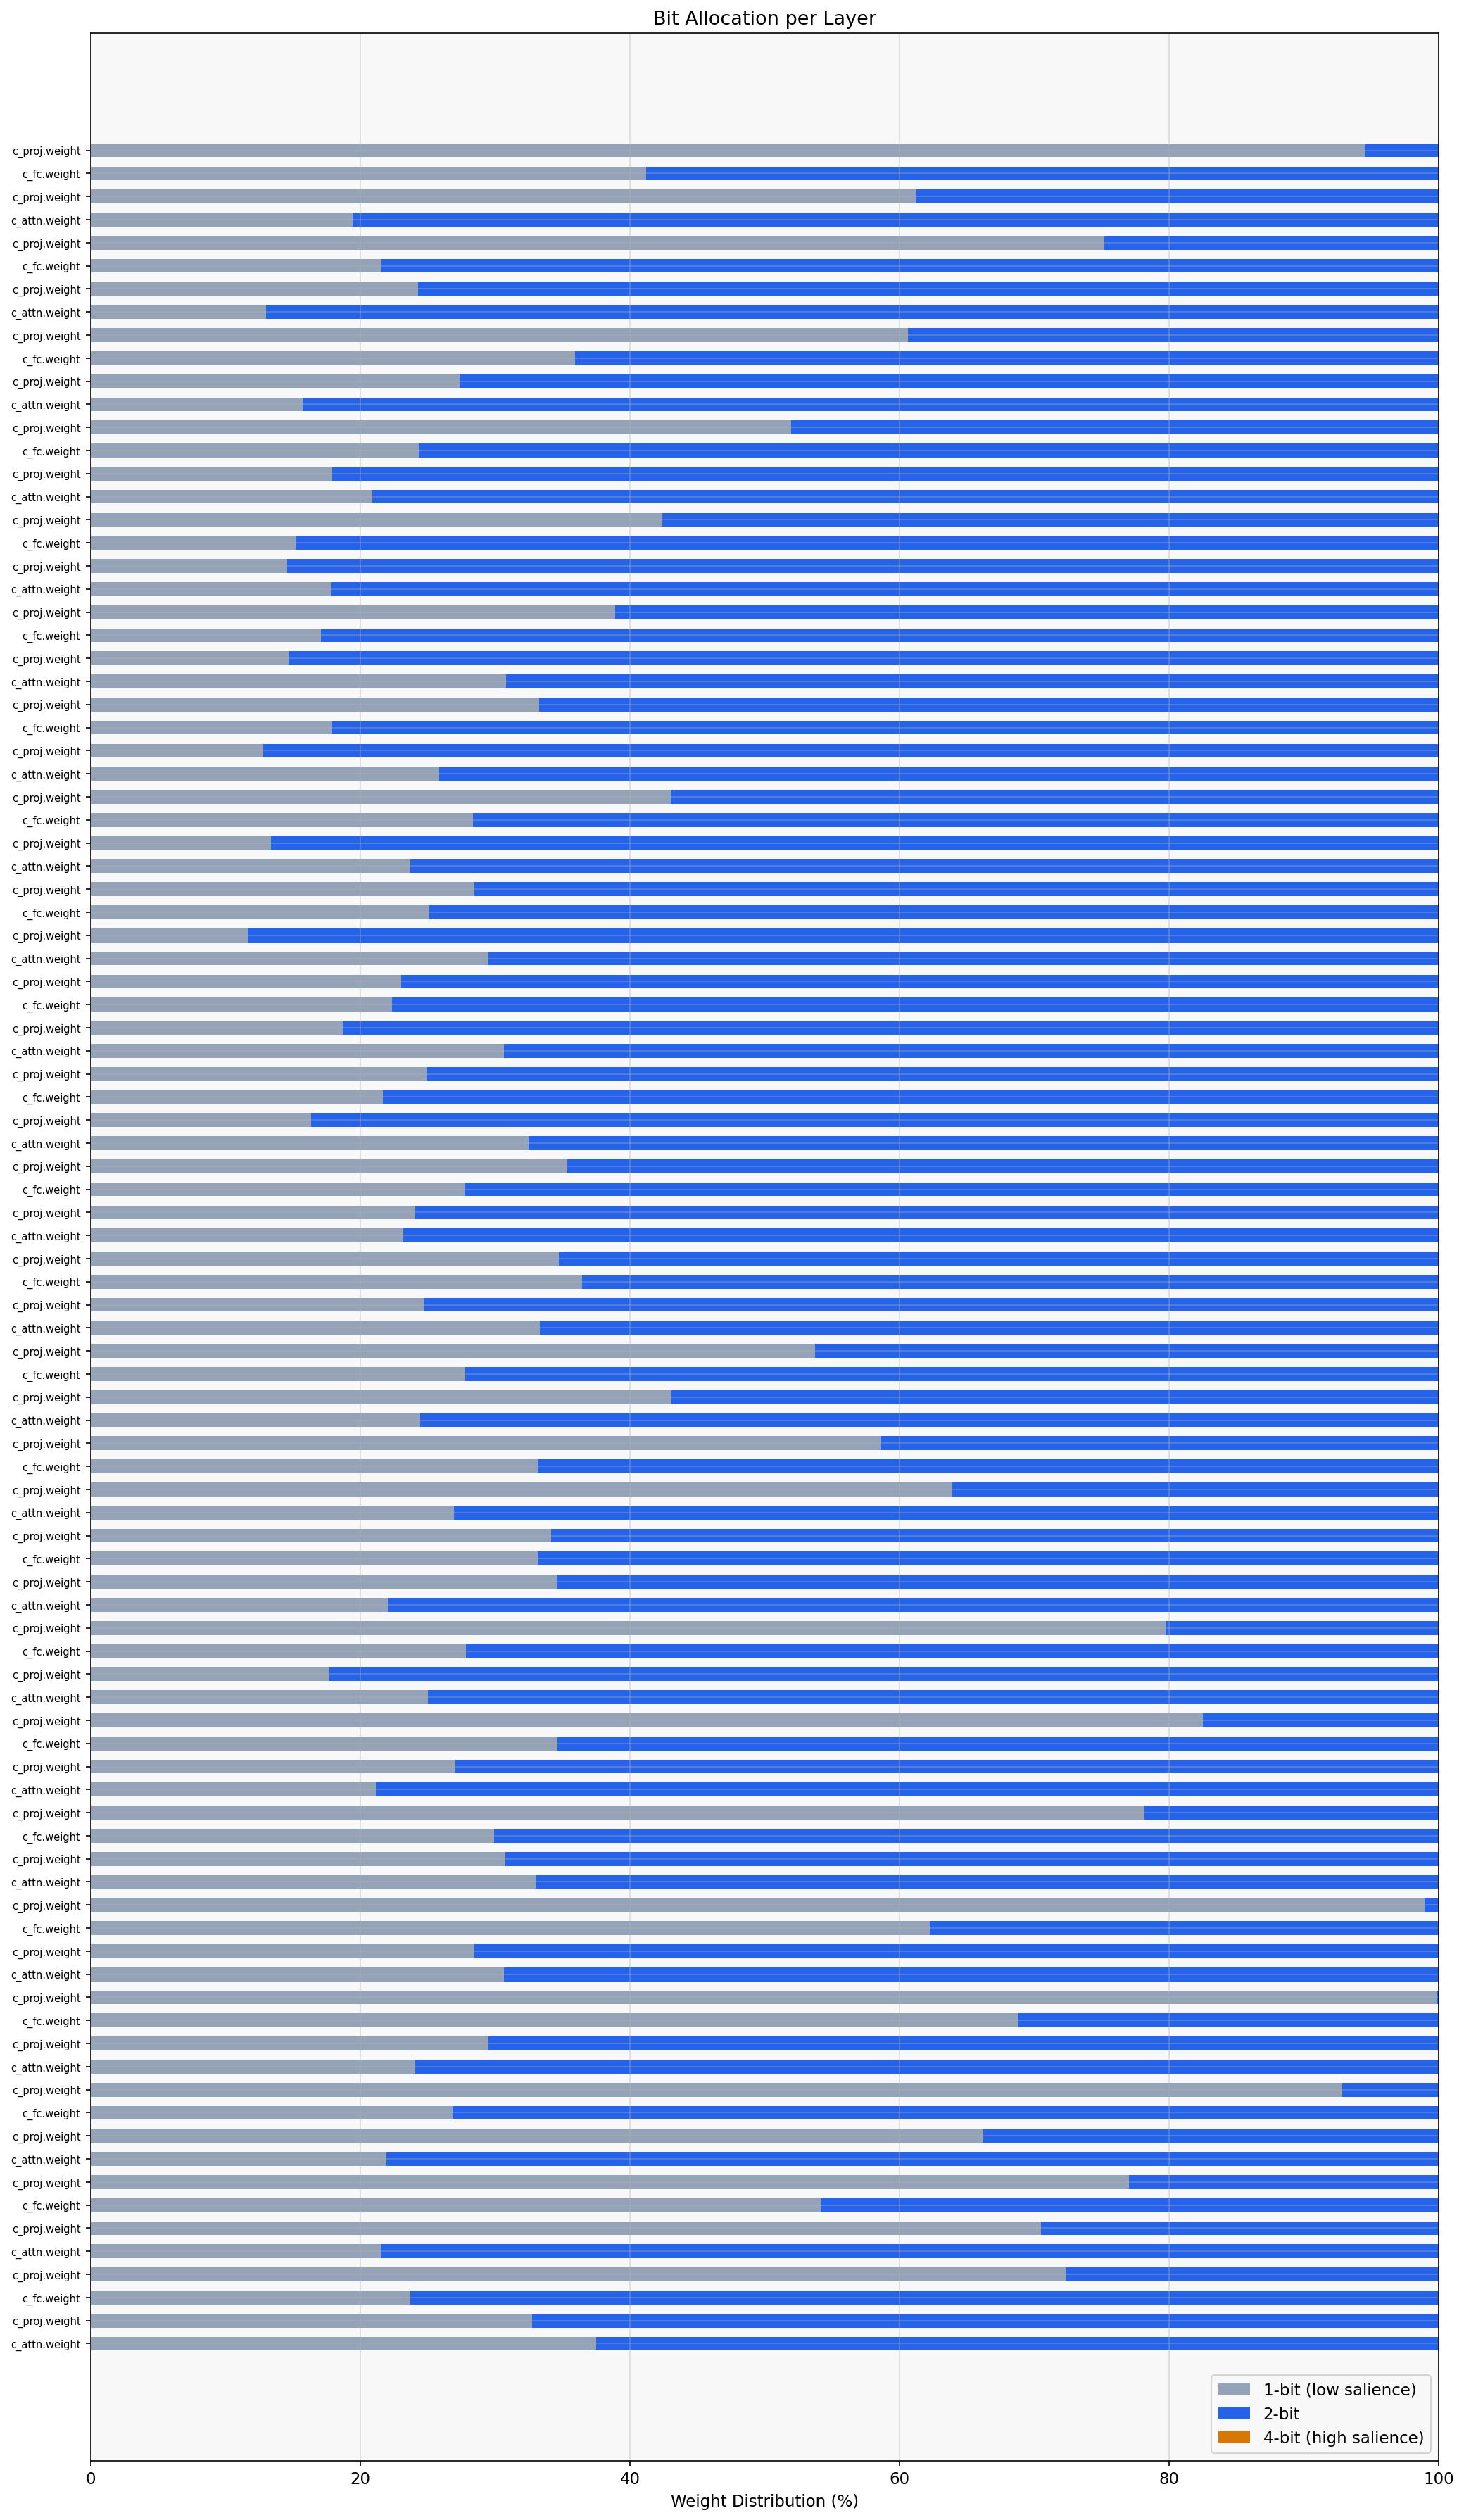


results/gpt2_full/plots/salience_distributions.png


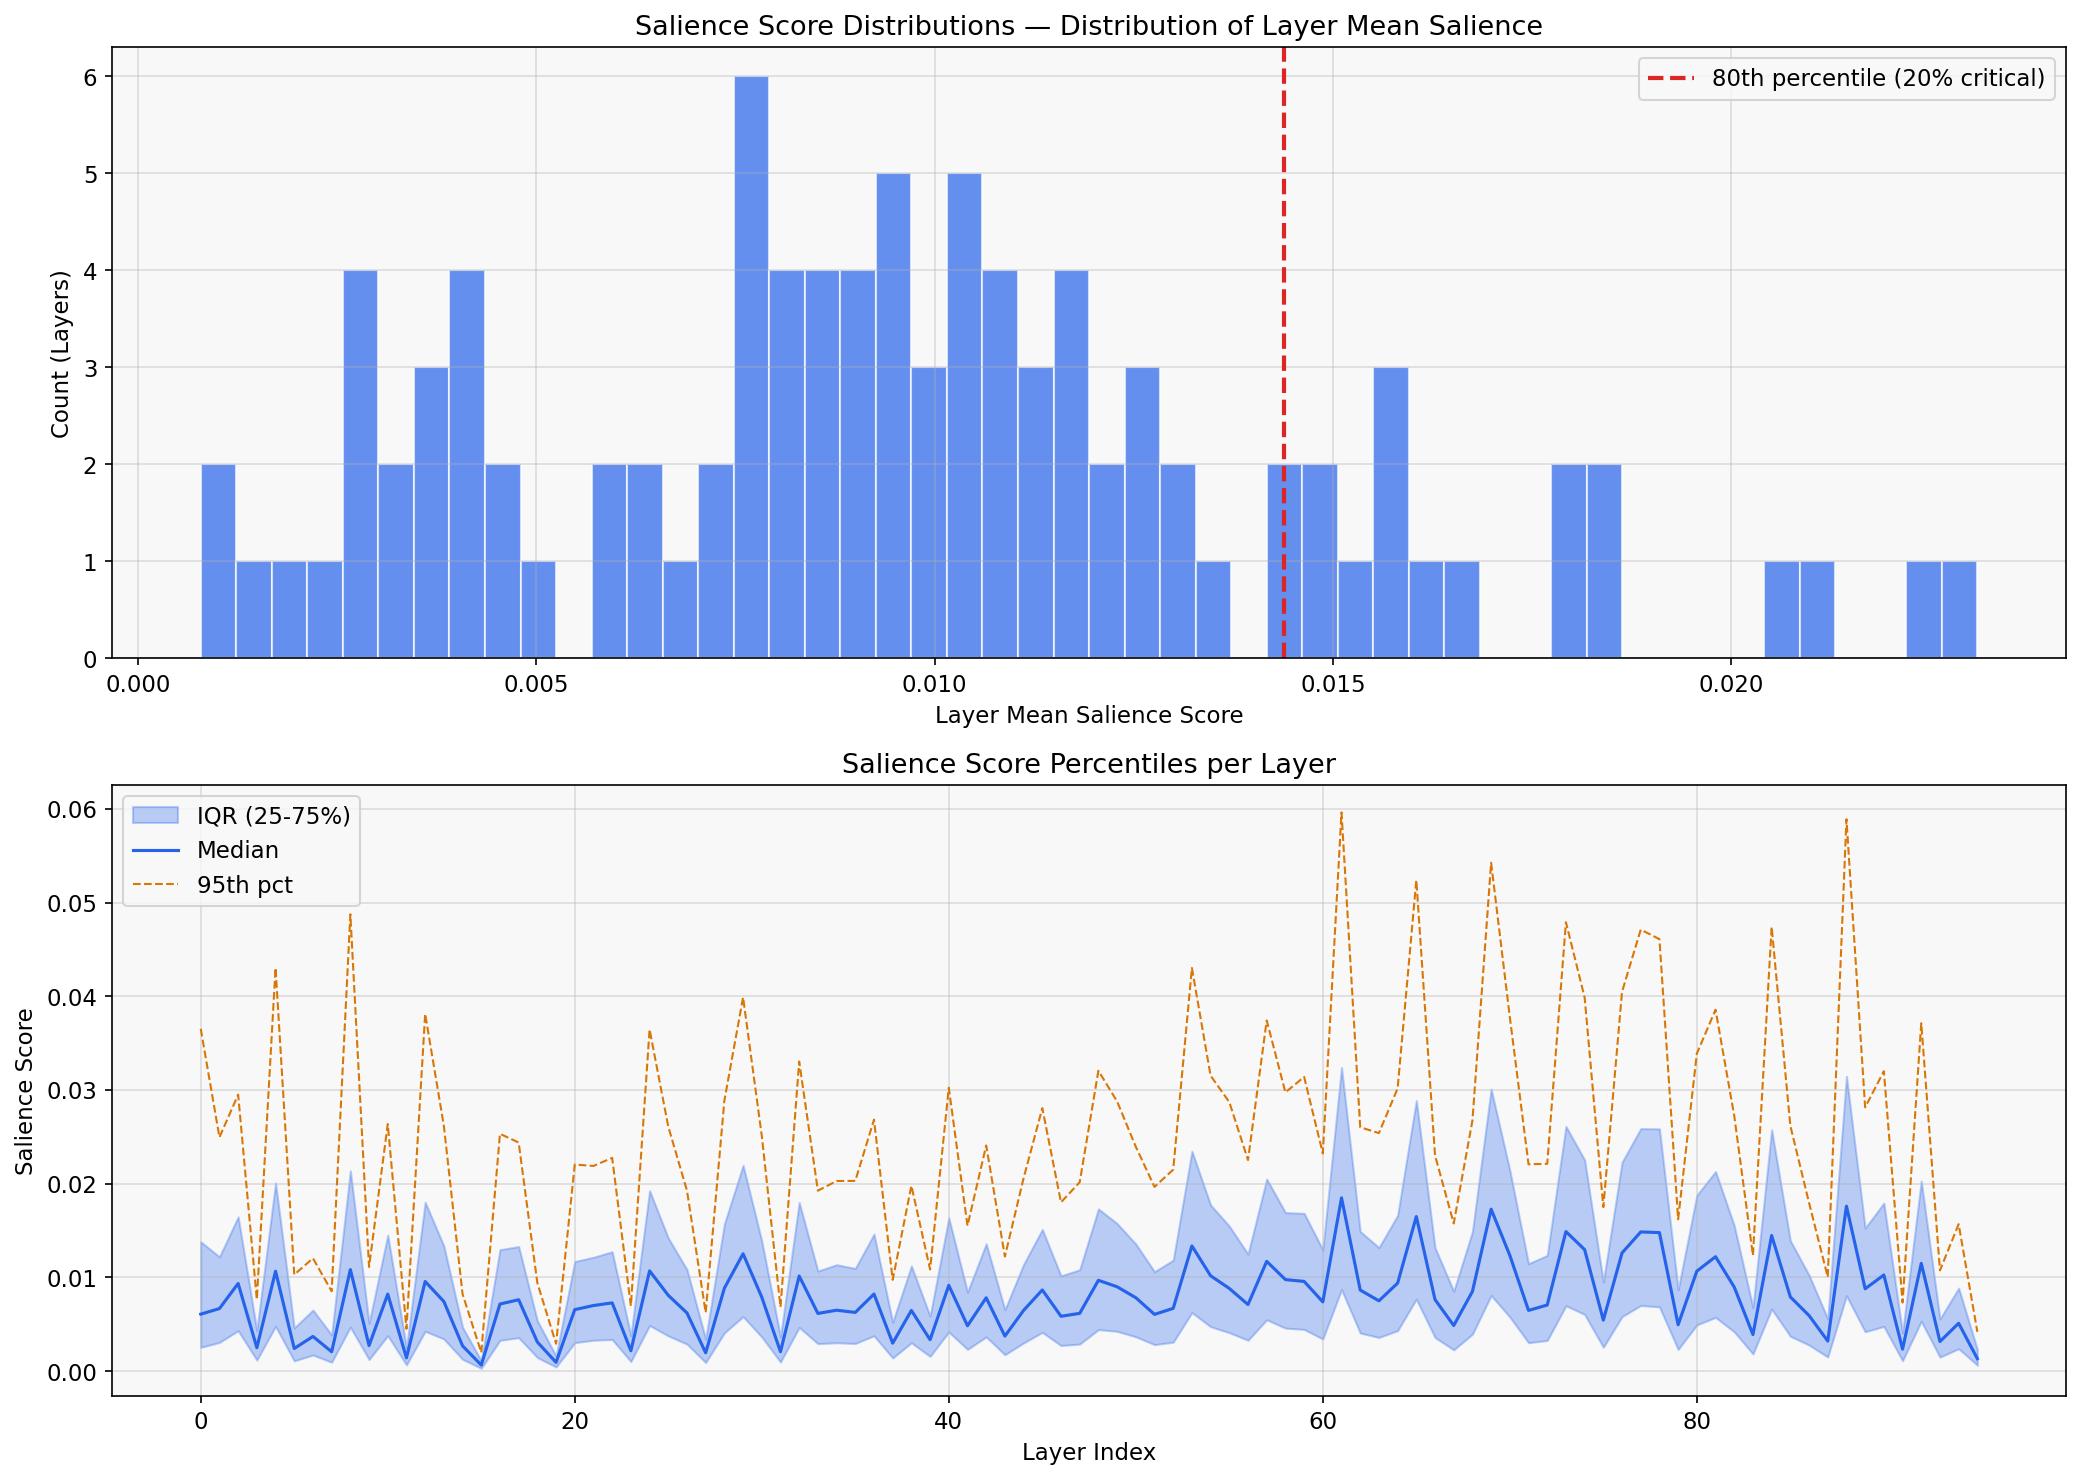

In [ ]:
print_results('results/gpt2_full')
print_ablation('results/gpt2_full')

import glob
from IPython.display import Image
for png in sorted(glob.glob('results/gpt2_full/plots/*.png')):
    print(f'\n{png}')
    display(Image(png))

---
## Experiment 3 — LLaMA-3.2-1B Full + All Ablations + MMLU (Milestone C)
**~90 min on T4** | Config: `configs/llama_full.yaml`

LLaMA-3.2-1B: baselines + ours + 6 ablation studies + MMLU 5-shot.
Evaluates WikiText-2, PTB, MMLU, latency, memory.

> Requires HuggingFace token with LLaMA-3.2 access (Step 3 above).

In [ ]:
import os, yaml
cfg = yaml.safe_load(open('configs/llama_full.yaml'))
cfg['run'] = ['ablations']
cfg['run_mmlu'] = False
cfg['run_latency'] = False
cfg['n_calibration_samples'] = 128
cfg['calibration_seq_len'] = 128
cfg['salience_metrics'] = ['magnitude_l1', 'magnitude_l2', 'gradient', 'activation']
cfg['ablation_types'] = ['salience_metric', 'bit_budget', 'calibration_size', 'granularity', 'quant_scheme', 'ensemble_weights']
out_cfg = 'configs/llama_ablations_run.yaml'
yaml.dump(cfg, open(out_cfg, 'w'))
print('Config written to', out_cfg)
print(yaml.dump(cfg))

Config written to configs/llama_ablations_run.yaml
ablation_types:
- calibration_size
- granularity
- quant_scheme
- ensemble_weights
block_size: 32
calibration_batch_size: 1
calibration_seq_len: 128
device: cuda
eval_datasets:
- wikitext2
- ptb
experiment_name: llama_full_milestone_c
granularity: weight
model_name: meta-llama/Llama-3.2-1B
n_calibration_samples: 128
output_dir: results/llama_full
quant_scheme: asymmetric
refine_scales: true
run:
- ablations
run_gptq: false
run_latency: false
run_mmlu: false
salience_metrics:
- magnitude_l1
- magnitude_l2
- gradient
- activation
target_avg_bits: 1.61



In [ ]:
os.system('python experiments/run_experiment.py --config configs/llama_full.yaml')

35072

In [ ]:
print_results('results/llama_full')
print_ablation('results/llama_full')

import glob
for png in sorted(glob.glob('results/llama_full/plots/*.png')):
    print(f'\n{png}')
    display(Image(png))


  llama_full_milestone_c_results.json
Method                   Bits    WT2 PPL    PTB PPL    MMLU%
------------------------------------------------------------
fp16                    16.00      10.96      11.32        -
uniform_int2             2.00  164165.15  168766.98        -
bitnet                   1.58   99786.03  104487.37        -


In [ ]:
import os
os.chdir('/content/Simplified-Quantization-for-Edge-Ready-Language-Models')
os.system('git pull')

0

In [ ]:
import subprocess, shutil, os

result = subprocess.run(
    ['python', 'experiments/run_experiment.py',
     '--config', 'configs/llama_ablations_run.yaml'],
    capture_output=True, text=True
)
print(result.stdout[-5000:])
if result.returncode != 0:
    print('STDERR:', result.stderr[-1000:])
print('Exit:', result.returncode)

# Copy results to Drive so they survive runtime resets
src  = '/content/Simplified-Quantization-for-Edge-Ready-Language-Models/results/llama_full'
dest = '/content/drive/MyDrive/smq_results/llama_full'
if os.path.exists(src):
    shutil.copytree(src, dest, dirs_exist_ok=True)
    print(f'Results saved to Drive: {dest}')
else:
    print('No results directory found — nothing copied')

1:30 [INFO] src.quantizer.salient_mask:   2bit: 529,699,480 (54.4%)
04:51:30 [INFO] src.quantizer.salient_mask:   4bit: 19,390,910 (2.0%)
04:51:30 [INFO] src.quantizer.salient_mask: 
[Phase 3] Applying mixed-precision quantization...
05:03:58 [INFO] src.quantizer.salient_mask: Quantized 112 tensors, avg L2 reconstruction error: 0.000084
05:03:58 [INFO] src.quantizer.salient_mask: Phase 3 complete in 748.4s
05:03:58 [INFO] src.quantizer.salient_mask: 
Quantization complete! Total time: 1045.1s
05:03:58 [INFO] src.quantizer.salient_mask: Timing breakdown: {'phase1_salience': 236.59558033943176, 'phase2_allocation': 60.11240863800049, 'phase3_quantization': 748.3820700645447}
05:03:58 [INFO] src.eval.evaluator: Evaluating perplexity on wikitext2...
05:06:53 [INFO] src.eval.evaluator: wikitext2 perplexity: 34778.76 (NLL: 10.4568)
05:06:55 [INFO] __main__:     PPL: 34778.76, avg bits: 1.604
05:06:56 [INFO] __main__:   Ablation config: default
05:06:56 [INFO] __main__: Loading model: meta-ll

---
## Summary — All Results